# Phase 1 — Storage & định dạng file

Phase 0 trả lời *"dữ liệu đi từ đâu tới đâu"*. Phase 1 trả lời một câu hẹp hơn nhưng
sâu hơn nhiều: **cùng một dữ liệu, lưu theo cách nào thì rẻ và nhanh?**

Nghe như chuyện vặt. Thực ra đây là tầng móng của cả lakehouse: Delta Lake (Phase 2)
chỉ là **một lớp transaction log đặt trên các file Parquet**. Không hiểu Parquet thì
Delta mãi mãi là hộp đen.

```
  7. Consumption      → JupyterLab            ← đang ngồi đây
  ...
  3. Compute engine   → DuckDB (tạm)             (Phase 3 thay bằng Spark)
  2. Table format     → chưa có                  (Phase 2: Delta Lake)
  1. Object storage   → MinIO                 ← PHASE 1 ĐÀO Ở TẦNG NÀY
```

## Ta sẽ tự tay đo, không tin lời đồn

| Bước | Câu hỏi | Cách trả lời |
|---|---|---|
| 1 | CSV / JSON / Parquet — cái nào nhẹ hơn, nhẹ bao nhiêu lần? | Ghi cùng 1 triệu dòng ra 5 kiểu file, đo byte |
| 2 | Nhanh hơn bao nhiêu lần? | Chạy 3 truy vấn trên từng định dạng, bấm giờ |
| 3 | Vì sao nhanh? | Mổ bụng file Parquet, đọc footer bằng tay |
| 4 | Sắp xếp dữ liệu có ăn thua gì không? | So cùng một filter trên file sắp xếp và không |
| 5 | Partition là gì, lợi thế nào? | Chia theo ngày, đo lại |
| 6 | **Sai có chủ đích:** partition quá mịn | Tự tay tạo ra *small files problem*, rồi chữa |

> **Cách dùng:** chạy từng cell, **nhìn con số của chính mình** rồi mới đọc phần giải thích.
> Con số bạn tự đo mới là thứ còn đọng lại sau 6 tháng, không phải câu chữ trong sách.

---
## Bước 1 — Cùng một dữ liệu, năm cách lưu

Ta lấy **trọn tháng 1/2024** (~3 triệu chuyến) × 10 cột, ghi ra 5 file khác nhau:

| File | Kiểu | Vì sao có mặt ở đây |
|---|---|---|
| `trips.csv` | text, theo dòng | định dạng phổ biến nhất thế giới |
| `trips.json` | text, theo dòng (NDJSON) | mỗi dòng lặp lại **tên cột** |
| `trips_none.parquet` | binary, theo cột, **không nén** | để tách bạch: bao nhiêu phần thắng nhờ *cột*, bao nhiêu nhờ *nén* |
| `trips_snappy.parquet` | binary, theo cột, nén Snappy | mặc định của Spark/Delta |
| `trips_zstd.parquet` | binary, theo cột, nén Zstd | nén mạnh hơn, tốn CPU hơn |

Cả năm file chứa **đúng cùng một dữ liệu, cùng thứ tự dòng**. Khác nhau duy nhất ở
cách xếp byte xuống đĩa. Chuẩn bị chỗ trống: tổng cộng khoảng 1 GB trong MinIO
(cell cuối notebook có lệnh dọn).

In [1]:
import os, time
import boto3, duckdb, pandas as pd

BUCKET = os.environ['LAKEHOUSE_BUCKET']
s3  = boto3.client('s3', endpoint_url=os.environ['AWS_ENDPOINT_URL'])
con = duckdb.connect()

# DuckDB cần biết đường vào MinIO — giống hệt Phase 0
con.sql(f"""
    CREATE OR REPLACE SECRET minio (
        TYPE s3,
        KEY_ID    '{os.environ['AWS_ACCESS_KEY_ID']}',
        SECRET    '{os.environ['AWS_SECRET_ACCESS_KEY']}',
        ENDPOINT  'minio:9000',
        USE_SSL   false,
        URL_STYLE 'path'
    )
""")

RAW  = f's3://{BUCKET}/raw/yellow_taxi/*.parquet'
LAB  = f's3://{BUCKET}/phase1'          # sân chơi riêng của phase này

# Một view chuẩn dùng chung cho mọi định dạng — cùng dữ liệu, cùng thứ tự
con.sql(f"""
    CREATE OR REPLACE VIEW src AS
    SELECT tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count,
           trip_distance, PULocationID, DOLocationID, payment_type,
           fare_amount, tip_amount, total_amount
    FROM read_parquet('{RAW}')
    WHERE tpep_pickup_datetime >= '2024-01-01'
      AND tpep_pickup_datetime <  '2024-02-01'
""")
print('Số dòng nguồn:', con.sql('SELECT count(*) FROM src').fetchone()[0])
con.sql('DESCRIBE src').show()

Số dòng nguồn: 2964606
┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ tpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ payment_type          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ fare_amount           │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ tip_amount     

In [2]:
# Ghi ra 5 định dạng. Mất khoảng 1-3 phút — phần lớn thời gian là ghi JSON.
targets = {
    'trips.csv'            : "(FORMAT CSV, HEADER)",
    'trips.json'           : "(FORMAT JSON)",
    'trips_none.parquet'   : "(FORMAT PARQUET, COMPRESSION UNCOMPRESSED)",
    'trips_snappy.parquet' : "(FORMAT PARQUET, COMPRESSION SNAPPY)",
    'trips_zstd.parquet'   : "(FORMAT PARQUET, COMPRESSION ZSTD)",
}

for name, opts in targets.items():
    t0 = time.perf_counter()
    con.sql(f"COPY (SELECT * FROM src) TO '{LAB}/formats/{name}' {opts}")
    print(f'✓ {name:24s} ghi mất {time.perf_counter()-t0:6.1f}s')

✓ trips.csv                ghi mất    1.5s
✓ trips.json               ghi mất    2.4s
✓ trips_none.parquet       ghi mất    0.7s
✓ trips_snappy.parquet     ghi mất    0.6s
✓ trips_zstd.parquet       ghi mất    0.5s


In [3]:
def liet_ke(prefix):
    """Trả về [(key, size_bytes)] cho mọi object dưới prefix — dùng lại nhiều lần bên dưới."""
    out, token = [], None
    while True:
        kw = dict(Bucket=BUCKET, Prefix=prefix)
        if token:
            kw['ContinuationToken'] = token
        r = s3.list_objects_v2(**kw)
        out += [(o['Key'], o['Size']) for o in r.get('Contents', [])]
        if not r.get('IsTruncated'):
            return out
        token = r['NextContinuationToken']

sizes = {k.split('/')[-1]: v for k, v in liet_ke('phase1/formats/')}
base  = sizes['trips.csv']

kq = pd.DataFrame(
    [(n, v/1e6, base/v) for n, v in sorted(sizes.items(), key=lambda x: -x[1])],
    columns=['file', 'MB', 'nhỏ hơn CSV (lần)']
).round(2)
kq

,file,MB,nhỏ hơn CSV (lần)
0,trips.json,727.24,0.29
1,trips.csv,210.83,1.00
2,trips_none.parquet,76.19,2.77
3,trips_snappy.parquet,57.35,3.68
4,trips_zstd.parquet,42.83,4.92


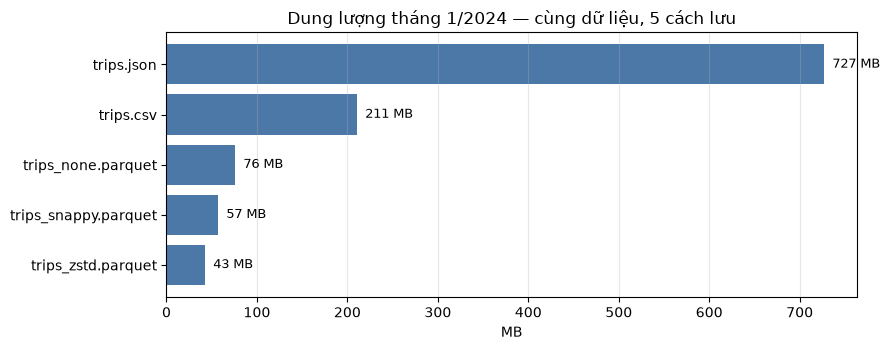

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(kq['file'][::-1], kq['MB'][::-1], color='#4C78A8')
for y, v in enumerate(kq['MB'][::-1]):
    ax.text(v, y, f'  {v:.0f} MB', va='center', fontsize=9)
ax.set_title('Dung lượng tháng 1/2024 — cùng dữ liệu, 5 cách lưu')
ax.set_xlabel('MB')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

### Đọc con số vừa hiện ra

Ba điều đáng chú ý — hãy đối chiếu với bảng của chính bạn:

**1. JSON to hơn CSV gấp mấy lần.** Vì mỗi dòng JSON lặp lại **tên của cả 10 cột**.
Ba triệu dòng là ba triệu lần viết lại chữ `tpep_pickup_datetime`. CSV khôn hơn: tên cột chỉ ghi
một lần ở dòng đầu tiên.

**2. Parquet *không nén* đã nhỏ hơn CSV rồi.** Đây là phần nhiều người bỏ qua.
Nó nhỏ hơn không nhờ nén, mà nhờ **kiểu dữ liệu thật**: một mốc thời gian trong CSV
là 19 ký tự = 19 byte text; trong Parquet là một số nguyên 64-bit = 8 byte. Còn với
cột lặp đi lặp lại nhiều, Parquet dùng **dictionary encoding**: lưu bảng tra các giá
trị riêng biệt một lần, rồi mỗi dòng chỉ ghi chỉ số trong bảng.

**3. Nén ăn rất đậm trên dữ liệu theo cột.** Đây là mấu chốt của columnar storage:
khi mọi giá trị của *cùng một cột* nằm sát nhau, chúng giống nhau — cùng kiểu, cùng
khoảng giá trị, nhiều giá trị lặp. Thuật toán nén sống nhờ sự lặp lại đó. Một dòng CSV
thì trộn lẫn ngày tháng, số thực, số nguyên cạnh nhau — chẳng có gì để lặp.

> **Một cách nhớ:** lưu theo dòng là *"ghi lần lượt từng hồ sơ"*; lưu theo cột là
> *"ghi hết cột Tên, rồi hết cột Tuổi, rồi hết cột Lương"*. Phân tích dữ liệu hầu như
> luôn hỏi *"trung bình cột Lương"*, hiếm khi hỏi *"cho tôi xem toàn bộ hồ sơ số 4.201"*.

---
## Bước 2 — Nhanh hơn bao nhiêu lần?

Nhẹ hơn chưa chắc nhanh hơn. Ta đo bằng 3 truy vấn có tính chất khác hẳn nhau:

| Truy vấn | Đòi hỏi gì |
|---|---|
| `Q1` — `count(*)` | Không cần dữ liệu, chỉ cần biết *có bao nhiêu dòng* |
| `Q2` — `avg(trip_distance)` | Chỉ cần **1 trên 10 cột** |
| `Q3` — lọc + gom nhóm | Cần vài cột và phải quét có điều kiện |

Hãy **đoán trước** kết quả rồi mới chạy. Đoán sai chính là chỗ học được nhiều nhất.

In [5]:
def bam_gio(sql, lan=3):
    """Chạy `lan` lần, lấy thời gian nhanh nhất — loại bớt nhiễu do máy đang bận."""
    times = []
    for _ in range(lan):
        t0 = time.perf_counter()
        con.sql(sql).fetchall()
        times.append(time.perf_counter() - t0)
    return min(times)

nguon = {
    'csv'            : f"read_csv('{LAB}/formats/trips.csv')",
    'json'           : f"read_json('{LAB}/formats/trips.json')",
    'parquet_none'   : f"read_parquet('{LAB}/formats/trips_none.parquet')",
    'parquet_snappy' : f"read_parquet('{LAB}/formats/trips_snappy.parquet')",
    'parquet_zstd'   : f"read_parquet('{LAB}/formats/trips_zstd.parquet')",
}

truy_van = {
    'Q1 count(*)'  : "SELECT count(*) FROM {t}",
    'Q2 avg 1 cột' : "SELECT avg(trip_distance) FROM {t}",
    'Q3 lọc+nhóm'  : ("SELECT payment_type, count(*), avg(total_amount) FROM {t} "
                      "WHERE trip_distance > 5 GROUP BY 1"),
}

rows = []
for ten, t in nguon.items():
    r = {'định dạng': ten}
    for q, sql in truy_van.items():
        r[q] = round(bam_gio(sql.format(t=t)), 3)
        print(f'{ten:16s} {q:14s} {r[q]:7.3f}s')
    rows.append(r)

do_nhanh = pd.DataFrame(rows).set_index('định dạng')
do_nhanh

csv              Q1 count(*)      0.272s
csv              Q2 avg 1 cột     0.247s
csv              Q3 lọc+nhóm      0.258s
json             Q1 count(*)      0.111s
json             Q2 avg 1 cột     0.122s
json             Q3 lọc+nhóm      0.129s
parquet_none     Q1 count(*)      0.001s
parquet_none     Q2 avg 1 cột     0.004s
parquet_none     Q3 lọc+nhóm      0.006s
parquet_snappy   Q1 count(*)      0.002s
parquet_snappy   Q2 avg 1 cột     0.004s
parquet_snappy   Q3 lọc+nhóm      0.005s
parquet_zstd     Q1 count(*)      0.001s
parquet_zstd     Q2 avg 1 cột     0.004s
parquet_zstd     Q3 lọc+nhóm      0.006s


,Q1 count(*),Q2 avg 1 cột,Q3 lọc+nhóm
định dạng,,,
csv,0.272,0.247,0.258
json,0.111,0.122,0.129
parquet_none,0.001,0.004,0.006
parquet_snappy,0.002,0.004,0.005
parquet_zstd,0.001,0.004,0.006


In [6]:
# Parquet nhanh gấp mấy lần CSV?
(do_nhanh.loc['csv'] / do_nhanh.loc['parquet_snappy']).round(1).to_frame('parquet nhanh hơn CSV (lần)')

,parquet nhanh hơn CSV (lần)
Q1 count(*),136.0
Q2 avg 1 cột,61.8
Q3 lọc+nhóm,51.6


### Vì sao chênh lệch lớn đến vậy

**Q1 `count(*)` — Parquet gần như tức thì.** Không phải vì nó đọc nhanh, mà vì nó
**không đọc gì cả**: số dòng nằm sẵn trong *footer* của file. CSV thì buộc phải tải
về toàn bộ và đếm ký tự xuống dòng — không có cách nào khác.

**Q2 chỉ lấy 1 cột — Parquet đọc đúng 1/10 file.** Vì các cột nằm tách nhau thành từng
khối riêng, engine chỉ tải khối `trip_distance`. Cơ chế này tên là **projection
pushdown** ("đẩy phép chọn cột xuống tận tầng đọc file"). CSV thì mỗi dòng là một chuỗi
text trộn lẫn 10 cột — muốn lấy cột thứ 4 vẫn phải đọc và **tách chuỗi** cả 10 cột.
Chi phí parse text ấy thường còn lớn hơn chi phí đọc đĩa.

**JSON chậm nhất** vì cộng thêm việc phân tích cú pháp dấu ngoặc và tên khoá từng dòng.

**Nén ảnh hưởng hai chiều.** File nén nhỏ → tải qua mạng nhanh hơn, nhưng tốn CPU giải
nén. Trên laptop đọc MinIO nội bộ, hai chiều gần như hoà nhau. Trên S3 thật qua
Internet, file nhỏ thắng đậm hơn nhiều — và đó mới là môi trường Parquet sinh ra để phục vụ.

> **Câu phỏng vấn kinh điển:** *"Vì sao Parquet nhanh hơn CSV?"*
> Trả lời hạng khá **không phải** "vì nó nén", mà là: **cột hoá** (chỉ đọc cột cần),
> **có kiểu dữ liệu** (không phải parse text), **có thống kê trong metadata**
> (bỏ qua được cả khối dữ liệu — bước 4 sẽ chứng minh). Nén chỉ là phần thưởng thêm.

---
## Bước 3 — Mổ bụng file Parquet

Nguyên tắc xuyên suốt lộ trình: **đọc file thô, không chỉ gọi API.**
Một file Parquet có cấu trúc như sau:

```
┌─────────────────────────────────────────┐
│ PAR1                        ← magic     │
│ ┌─────────── Row group 0 ─────────────┐ │   một "lô" vài trăm nghìn dòng
│ │ column chunk: pickup_datetime       │ │   ↳ trong lô, dữ liệu chia theo CỘT
│ │ column chunk: trip_distance         │ │
│ │ ...                                 │ │
│ └─────────────────────────────────────┘ │
│ ┌─────────── Row group 1 ─────────────┐ │
│ │ ...                                 │ │
│ └─────────────────────────────────────┘ │
│ FOOTER: schema, số dòng, và với MỖI     │ ← đọc footer là biết hết,
│ column chunk: vị trí byte + min/max     │   không cần đọc dữ liệu
│ PAR1                                    │
└─────────────────────────────────────────┘
```

Engine luôn đọc **footer trước**. Từ footer nó biết cột cần nằm ở byte nào, và giá trị
min/max trong từng khối là bao nhiêu. Hai thông tin đó đẻ ra toàn bộ phép màu ở bước 4.

In [7]:
import pyarrow.parquet as pq, pyarrow.fs as pafs

fs = pafs.S3FileSystem(
    endpoint_override=os.environ['AWS_ENDPOINT_URL'],
    access_key=os.environ['AWS_ACCESS_KEY_ID'],
    secret_key=os.environ['AWS_SECRET_ACCESS_KEY'],
    scheme='http',
)
pf = pq.ParquetFile(fs.open_input_file(f'{BUCKET}/phase1/formats/trips_snappy.parquet'))
m  = pf.metadata

print(f'Số dòng      : {m.num_rows:,}')
print(f'Số row group : {m.num_row_groups}   → mỗi lô ~{m.num_rows // m.num_row_groups:,} dòng')
print(f'Số cột       : {m.num_columns}')
print(f'Người tạo    : {m.created_by}')

Số dòng      : 2,964,606
Số row group : 25   → mỗi lô ~118,584 dòng
Số cột       : 10
Người tạo    : DuckDB version v1.5.5 (build d8cdaa33fd)


In [8]:
# Bên trong row group 0: mỗi cột tốn bao nhiêu byte, nén kiểu gì, mã hoá ra sao
rg = m.row_group(0)
pd.DataFrame([{
    'cột'       : rg.column(i).path_in_schema,
    'kiểu'      : str(rg.column(i).physical_type),
    'nén'       : rg.column(i).compression,
    'byte gốc'  : rg.column(i).total_uncompressed_size,
    'byte nén'  : rg.column(i).total_compressed_size,
    'tỉ lệ nén' : round(rg.column(i).total_uncompressed_size / rg.column(i).total_compressed_size, 1),
    'encoding'  : ','.join(str(e) for e in rg.column(i).encodings),
} for i in range(rg.num_columns)])

,cột,kiểu,nén,byte gốc,byte nén,tỉ lệ nén,encoding
0,tpep_pickup_datetime,INT64,SNAPPY,983071,638343,1.5,PLAIN
1,tpep_dropoff_datetime,INT64,SNAPPY,983071,657259,1.5,PLAIN
2,passenger_count,INT64,SNAPPY,61802,41322,1.5,PLAIN_DICTIONARY
3,trip_distance,DOUBLE,SNAPPY,207610,196797,1.1,PLAIN_DICTIONARY
4,PULocationID,INT32,SNAPPY,124326,124158,1.0,PLAIN_DICTIONARY
5,DOLocationID,INT32,SNAPPY,124424,124438,1.0,PLAIN_DICTIONARY
6,payment_type,INT64,SNAPPY,46498,31138,1.5,PLAIN_DICTIONARY
7,fare_amount,DOUBLE,SNAPPY,161656,158454,1.0,PLAIN_DICTIONARY
8,tip_amount,DOUBLE,SNAPPY,202431,180202,1.1,PLAIN_DICTIONARY
9,total_amount,DOUBLE,SNAPPY,255138,232675,1.1,PLAIN_DICTIONARY


Hai cột đáng soi kỹ:

**Cột `encoding`.** `PLAIN_DICTIONARY` (hoặc `RLE_DICTIONARY` ở phiên bản mới) nghĩa là
Parquet đã **tự** phát hiện cột đó lặp nhiều và chuyển sang từ điển: lưu danh sách giá
trị riêng biệt một lần, mỗi dòng chỉ ghi số thứ tự. Không ai bảo nó làm — nó tự quyết
định lúc ghi. Cột `tpep_pickup_datetime` thì để `PLAIN`, vì gần như mọi mốc thời gian
đều khác nhau, làm từ điển chỉ tổ tốn thêm.

**Cột `tỉ lệ nén` khiêm tốn hơn ta tưởng** (chỉ 1.0-1.5 lần). Đừng vội kết luận "nén vô
dụng": phần thắng lớn đã bị **encoding gặt trước rồi** — Snappy chỉ còn nhặt phần thừa
trên dữ liệu vốn đã gọn. Muốn thấy toàn cảnh, hãy so `trips_none.parquet` (25 MB, cũng
đã có encoding) với `trips.csv` ở bước 1. Đó mới là khoảng cách thật giữa
*"có kiểu dữ liệu + có encoding"* và *"text trần"*.

Những khái niệm này sẽ quay lại rất nhiều: Phase 2 sẽ thấy Delta `OPTIMIZE` chính là
**ghi lại file để row group to và gọn hơn**; Phase 3 sẽ thấy Spark chia task theo row group.

In [9]:
# Thống kê min/max của từng row group — chìa khoá của bước 4
pd.DataFrame([{
    'row_group'  : i,
    'số dòng'    : m.row_group(i).num_rows,
    'pickup_min' : m.row_group(i).column(0).statistics.min,
    'pickup_max' : m.row_group(i).column(0).statistics.max,
} for i in range(m.num_row_groups)])

,row_group,số dòng,pickup_min,pickup_max
0,0,122880,2024-01-01 00:00:00,2024-01-03 22:46:45
1,1,122880,2024-01-02 17:00:59,2024-01-04 23:38:18
2,2,122880,2024-01-04 00:00:00,2024-01-05 23:31:37
3,3,122880,2024-01-05 13:27:23,2024-01-06 19:01:28
4,4,122880,2024-01-06 17:20:10,2024-01-08 15:01:22
5,5,122880,2024-01-08 12:59:42,2024-01-09 21:03:22
6,6,122880,2024-01-09 19:37:16,2024-01-11 11:02:02
7,7,122880,2024-01-11 09:58:24,2024-01-12 23:23:29
8,8,124915,2024-01-12 13:35:56,2024-01-13 23:51:06
9,9,122880,2024-01-13 16:03:50,2024-01-15 01:59:39


---
## Bước 4 — Thống kê chỉ có ích khi dữ liệu được sắp xếp

Nhìn lại bảng min/max vừa rồi: các row group nối đuôi nhau theo thời gian khá gọn.
Ta **gặp may** — dữ liệu gốc của NYC vốn đã được ghi gần đúng thứ tự chuyến đi.

Ngoài đời hiếm khi may như thế: dữ liệu thường gộp từ nhiều nguồn, nhiều luồng ghi song
song, đến đâu ghi đó. Ta mô phỏng đúng tình huống đó bằng cách **xáo trộn** rồi ghi lại,
và ghi thêm một bản **sắp xếp theo thời gian** để đối chứng. Cùng dữ liệu, cùng dung
lượng, chỉ khác thứ tự dòng bên trong.

In [10]:
for ten, thu_tu in [('shuffled', 'random()'), ('sorted', 'tpep_pickup_datetime')]:
    con.sql(f"""
        COPY (SELECT * FROM src ORDER BY {thu_tu})
        TO '{LAB}/order/trips_{ten}.parquet' (FORMAT PARQUET, COMPRESSION SNAPPY)
    """)

def bang_stats(ten):
    md = pq.ParquetFile(fs.open_input_file(f'{BUCKET}/phase1/order/trips_{ten}.parquet')).metadata
    return pd.DataFrame([{
        f'{ten}_min': md.row_group(i).column(0).statistics.min,
        f'{ten}_max': md.row_group(i).column(0).statistics.max,
    } for i in range(md.num_row_groups)])

# Trái: xáo trộn — lô nào cũng trải khắp tháng. Phải: sắp xếp — mỗi lô một lát thời gian.
pd.concat([bang_stats('shuffled'), bang_stats('sorted')], axis=1).head(12)

,shuffled_min,shuffled_max,sorted_min,sorted_max
0,2024-01-01 00:00:36,2024-01-31 23:59:06,2024-01-01 00:00:00,2024-01-02 15:43:48
1,2024-01-01 00:02:09,2024-01-31 23:59:43,2024-01-02 15:43:48,2024-01-04 07:50:06
2,2024-01-01 00:00:17,2024-01-31 23:59:15,2024-01-04 07:50:07,2024-01-05 11:37:12
3,2024-01-01 00:00:11,2024-01-31 23:59:54,2024-01-05 11:37:13,2024-01-06 15:23:52
4,2024-01-01 00:02:16,2024-01-31 23:59:44,2024-01-06 15:23:52,2024-01-08 07:11:46
5,2024-01-01 00:00:04,2024-01-31 23:59:24,2024-01-08 07:11:46,2024-01-09 15:23:44
6,2024-01-01 00:00:58,2024-01-31 23:59:29,2024-01-09 15:23:44,2024-01-10 19:59:03
7,2024-01-01 00:01:39,2024-01-31 23:59:51,2024-01-10 19:59:04,2024-01-11 23:47:29
8,2024-01-01 00:00:00,2024-01-31 23:59:05,2024-01-11 23:47:29,2024-01-13 09:35:28
9,2024-01-01 00:00:11,2024-01-31 23:59:43,2024-01-13 09:35:30,2024-01-14 12:58:23


In [11]:
LOC = ("SELECT count(*), avg(total_amount) FROM read_parquet('{f}') "
       "WHERE tpep_pickup_datetime >= '2024-01-15' AND tpep_pickup_datetime < '2024-01-16'")

t_loan = bam_gio(LOC.format(f=f'{LAB}/order/trips_shuffled.parquet'))
t_xep  = bam_gio(LOC.format(f=f'{LAB}/order/trips_sorted.parquet'))

print(f'Xáo trộn   : {t_loan:.3f}s')
print(f'Sắp xếp    : {t_xep:.3f}s   → nhanh hơn {t_loan/t_xep:.1f} lần')

# Bằng chứng: đếm số row group thật sự bị đọc
for ten in ['shuffled', 'sorted']:
    md = pq.ParquetFile(fs.open_input_file(f'{BUCKET}/phase1/order/trips_{ten}.parquet')).metadata
    can_doc = sum(
        1 for i in range(md.num_row_groups)
        if not (md.row_group(i).column(0).statistics.max < pd.Timestamp('2024-01-15')
                or md.row_group(i).column(0).statistics.min >= pd.Timestamp('2024-01-16'))
    )
    print(f'{ten:9s}: phải đọc {can_doc}/{md.num_row_groups} row group')

Xáo trộn   : 0.008s
Sắp xếp    : 0.004s   → nhanh hơn 2.3 lần
shuffled : phải đọc 25/25 row group
sorted   : phải đọc 2/25 row group


Cùng một dữ liệu, cùng kích thước, cùng truy vấn — chỉ khác **thứ tự dòng bên trong file**.
Bản xáo trộn phải đọc **toàn bộ** row group; bản sắp xếp chỉ đọc một hai lô.

Cơ chế tên là **predicate pushdown + row-group skipping**: điều kiện `WHERE` được đẩy
xuống tầng đọc file; engine so nó với min/max trong footer và **bỏ qua nguyên row
group** nếu chắc chắn không dòng nào khớp. Với file đã sắp xếp, chỉ 1-2 lô cần đọc.

Đây không phải mẹo vặt. Đây chính là thứ Databricks bán dưới cái tên **Z-ORDER**
(bản mới hơn: *liquid clustering*) — sắp dữ liệu theo cột hay dùng trong `WHERE` để
thống kê trở nên hữu dụng. Phase 2 bạn sẽ gõ `OPTIMIZE ... ZORDER BY` và lúc đó
đã biết chính xác **nó làm gì bên dưới**.

> **Rút ra:** thống kê trong metadata chỉ có giá trị khi dữ liệu có *tính cụm*
> (clustering). Ghi dữ liệu theo thứ tự ngẫu nhiên = vứt bỏ một nửa sức mạnh của Parquet.

---
## Bước 5 — Partition: bỏ qua dữ liệu ở mức thư mục

Sắp xếp giúp bỏ qua *row group*. Partition đi xa hơn: bỏ qua **cả file**, thậm chí
không cần mở file ra xem.

Ý tưởng đơn giản đến bất ngờ — mã hoá giá trị vào **tên thư mục**:

```
phase1/by_day/ngay=2024-01-14/data_0.parquet
phase1/by_day/ngay=2024-01-15/data_0.parquet     ← WHERE ngay='2024-01-15'
phase1/by_day/ngay=2024-01-16/data_0.parquet        chỉ đọc đúng thư mục này
```

Kiểu đặt tên `cột=giá_trị` này gọi là **Hive-style partitioning**. Nó là quy ước chung
của cả hệ sinh thái: Spark, Trino, DuckDB, Delta đều hiểu.

In [12]:
con.sql(f"""
    COPY (SELECT *, CAST(tpep_pickup_datetime AS DATE) AS ngay FROM src)
    TO '{LAB}/by_day' (FORMAT PARQUET, PARTITION_BY (ngay), OVERWRITE_OR_IGNORE)
""")

f_day = liet_ke('phase1/by_day/')
print(f'Số file : {len(f_day)}')
print(f'Trung bình mỗi file: {sum(s for _, s in f_day)/len(f_day)/1e6:.1f} MB')
for k, s in sorted(f_day)[:3]:
    print(f'   {s/1e6:6.1f} MB  {k}')

Số file : 31
Trung bình mỗi file: 1.9 MB
      1.7 MB  phase1/by_day/ngay=2024-01-01/data_0.parquet
      1.5 MB  phase1/by_day/ngay=2024-01-02/data_0.parquet
      1.6 MB  phase1/by_day/ngay=2024-01-03/data_0.parquet


In [13]:
# So với file xáo trộn ở bước 4 — trường hợp thống kê không giúp được gì
CO_PART = (f"SELECT count(*), avg(total_amount) "
           f"FROM read_parquet('{LAB}/by_day/**/*.parquet', hive_partitioning=true) "
           "WHERE ngay = DATE '2024-01-15'")
KHONG   = (f"SELECT count(*), avg(total_amount) "
           f"FROM read_parquet('{LAB}/order/trips_shuffled.parquet') "
           "WHERE CAST(tpep_pickup_datetime AS DATE) = DATE '2024-01-15'")

a, b = bam_gio(CO_PART), bam_gio(KHONG)
print(f'Có partition       : {a:.3f}s')
print(f'Một file, phải quét: {b:.3f}s   → partition nhanh hơn {b/a:.1f} lần\n')

# Bằng chứng: engine chỉ chạm vào đúng một thư mục trên 31
print(con.sql('EXPLAIN ' + CO_PART).fetchall()[0][1])

Có partition       : 0.005s
Một file, phải quét: 0.007s   → partition nhanh hơn 1.4 lần

┌───────────────────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│        Aggregates:        │
│        count_star()       │
│          avg(#0)          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│        total_amount       │
│                           │
│        ~81,013 rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│        READ_PARQUET       │
│    ────────────────────   │
│         Function:         │
│        READ_PARQUET       │
│                           │
│        Projections:       │
│        total_amount       │
│                           │
│       File Filters:       │
│(ngay = '2024-01-15'::DATE)│
│                           │
│    Scanning Files: 1/31   │
│                           │
│        ~81,013 rows       │
└───────────────────────────┘



Trong output của `EXPLAIN`, tìm dòng `Scanning Files` (hoặc `File Filters`) — engine
loại bỏ 30 thư mục kia mà **không mở file nào**. Cơ chế này tên là **partition pruning**.

Chú ý điểm tinh tế: câu bên phải phải viết `CAST(tpep_pickup_datetime AS DATE) = ...`,
tức là **gọi hàm lên cột** trước khi so sánh. Nhiều engine gặp thế là không đẩy điều
kiện xuống được nữa — thống kê min/max chịu thua và phải quét sạch. Còn với partition,
giá trị `ngay` nằm ngay trên **tên thư mục**, chẳng cần đọc file nào để biết.

**Chọn cột nào để partition?** Ba tiêu chí, thiếu một là hỏng:

1. **Hay xuất hiện trong `WHERE`.** Partition theo cột không ai lọc = không lợi gì,
   chỉ tổ đẻ ra file nhỏ.
2. **Cardinality thấp** (ít giá trị khác nhau). Ngày → 31 giá trị/tháng: tốt.
   `PULocationID` → 265: đã hơi nhiều. `trip_id` → 1 triệu: thảm hoạ.
3. **Mỗi partition phải đủ to.** Ngưỡng công nghiệp: **mỗi file 128 MB – 1 GB**.
   Nhỏ hơn nhiều là dấu hiệu bạn đang chia quá mịn.

Bước tiếp theo ta cố tình vi phạm tiêu chí 2 và 3 để thấy giá phải trả.

---
## Bước 6 · SAI CÓ CHỦ ĐÍCH — tự tay tạo ra *small files problem*

Nguyên tắc số 1 của lộ trình: **cố ý làm sai trước, sửa sau.** Người chỉ đọc lý thuyết
biết câu "small files problem là xấu". Người từng nhìn đồng hồ nhảy số vì nó thì
*nhớ suốt đời* — và trả lời được câu phỏng vấn *"kể một lần pipeline của bạn hỏng"*.

Ta partition theo **ngày × giờ**: 31 × 24 = 744 thư mục. Nghe vẫn "có lý" — rất nhiều
người thật sự làm thế trong production. Để ý con số file thực tế sẽ còn *lớn hơn* 744:
mỗi luồng ghi song song đẻ ra một file riêng trong cùng một thư mục. Đây chính là cách
small files sinh sôi ngoài đời — không ai cố ý tạo ra chúng cả.

In [14]:
t0 = time.perf_counter()
con.sql(f"""
    COPY (SELECT *, CAST(tpep_pickup_datetime AS DATE) AS ngay,
                 hour(tpep_pickup_datetime)         AS gio
          FROM src)
    TO '{LAB}/too_fine' (FORMAT PARQUET, PARTITION_BY (ngay, gio), OVERWRITE_OR_IGNORE)
""")
print(f'Ghi mất {time.perf_counter()-t0:.1f}s')

f_min = liet_ke('phase1/too_fine/')
f_day = liet_ke('phase1/by_day/')

pd.DataFrame([
    {'cách chia': 'theo ngày',     'số file': len(f_day),
     'tổng MB': sum(s for _, s in f_day)/1e6, 'MB/file': sum(s for _, s in f_day)/len(f_day)/1e6},
    {'cách chia': 'theo ngày+giờ', 'số file': len(f_min),
     'tổng MB': sum(s for _, s in f_min)/1e6, 'MB/file': sum(s for _, s in f_min)/len(f_min)/1e6},
]).round(2)

Ghi mất 4.3s


,cách chia,số file,tổng MB,MB/file
0,theo ngày,31,58.62,1.89
1,theo ngày+giờ,1434,69.64,0.05


In [15]:
# Cùng một câu hỏi "cả tháng", chạy trên hai cách chia
CAU_HOI = ("SELECT payment_type, count(*), round(avg(total_amount),2) "
           "FROM read_parquet('{p}', hive_partitioning=true) GROUP BY 1 ORDER BY 1")

t_ngay = bam_gio(CAU_HOI.format(p=f'{LAB}/by_day/**/*.parquet'))
t_min  = bam_gio(CAU_HOI.format(p=f'{LAB}/too_fine/**/*.parquet'))

print(f'{len(f_day):4d} file (theo ngày)     : {t_ngay:.3f}s')
print(f'{len(f_min):4d} file (theo ngày+giờ) : {t_min:.3f}s   → CHẬM hơn {t_min/t_ngay:.1f} lần')

  31 file (theo ngày)     : 0.010s
1434 file (theo ngày+giờ) : 0.117s   → CHẬM hơn 11.8 lần


### Vì sao nhiều file nhỏ lại đắt đến thế

Chi phí không nằm ở lượng byte — **tổng dung lượng gần như không đổi**, thậm chí còn
*phình ra*, vì mỗi file Parquet phải mang theo footer, schema và từ điển riêng của nó.
Chi phí nằm ở **số lần phải hỏi storage**:

| Với mỗi file, engine phải | MinIO ở localhost | S3 thật |
|---|---|---|
| Gọi `LIST` để biết file tồn tại | ~vài ms | ~10-100 ms |
| Mở file, đọc footer | ~vài ms | ~10-50 ms |
| Đọc dữ liệu | tuỳ kích thước | tuỳ kích thước |

Hơn một nghìn file × vài chục mili giây = hàng chục giây **chỉ để chào hỏi**, chưa đọc
byte dữ liệu nào. Object storage tính tiền và tính thời gian theo **số request**, không phải
theo byte. Đây là khác biệt căn bản so với ổ cứng thường — và là lý do *small files
problem* là bệnh kinh niên của mọi data lake.

Trên môi trường thật còn hai vết thương nữa mà laptop không cho bạn thấy:
- **Spark tạo 1 task cho mỗi file.** Nghìn file nhỏ = nghìn task, mỗi task chạy 50 ms
  nhưng chi phí khởi động task là 100 ms. Cluster bận rộn mà chẳng làm được gì.
- **Catalog phải theo dõi từng partition.** Hàng chục nghìn partition làm chậm chính
  việc *lập kế hoạch* truy vấn, trước cả khi đọc dữ liệu.

In [16]:
# ── Chữa bệnh: gộp file lại (compaction) ──
t0 = time.perf_counter()
con.sql(f"""
    COPY (SELECT * FROM read_parquet('{LAB}/too_fine/**/*.parquet', hive_partitioning=true)
          ORDER BY tpep_pickup_datetime)
    TO '{LAB}/compacted/trips.parquet' (FORMAT PARQUET, COMPRESSION SNAPPY)
""")
print(f'Gộp mất {time.perf_counter()-t0:.1f}s')

f_gop = liet_ke('phase1/compacted/')
t_gop = bam_gio(CAU_HOI.format(p=f'{LAB}/compacted/trips.parquet'))

print(f'\n{len(f_min):4d} file →   {t_min:.3f}s')
print(f'{len(f_gop):4d} file →   {t_gop:.3f}s   → nhanh hơn {t_min/t_gop:.1f} lần')
print(f'\nTổng dung lượng: {sum(s for _, s in f_min)/1e6:.1f} MB  →  {sum(s for _, s in f_gop)/1e6:.1f} MB')

Gộp mất 0.8s

1434 file →   0.117s
   1 file →   0.007s   → nhanh hơn 16.7 lần

Tổng dung lượng: 69.6 MB  →  53.4 MB


Việc bạn vừa làm bằng tay — **đọc nhiều file nhỏ, ghi lại thành ít file to, sắp xếp
theo cột hay lọc** — có một cái tên trong Databricks: **`OPTIMIZE`** (kèm `ZORDER BY`).
Ở Phase 2 nó sẽ chỉ là một câu lệnh SQL. Nhưng bạn sẽ biết chính xác nó làm gì, vì
hôm nay bạn đã tự viết nó ra.

Và đây là chỗ Delta Lake hơn hẳn một thư mục Parquet trần: khi bạn gộp file bằng tay
như trên, **nếu có người đang query giữa chừng thì họ thấy dữ liệu hỏng** — file cũ đã
bị xoá, file mới chưa ghi xong. Delta sinh ra để giải quyết đúng chuyện đó, bằng
transaction log. Đó là toàn bộ nội dung Phase 2.

In [ ]:
# Dọn sân chơi (tuỳ chọn — bỏ dấu # nếu muốn giải phóng chỗ trong MinIO)
# keys = [k for k, _ in liet_ke('phase1/')]
# for i in range(0, len(keys), 1000):
#     s3.delete_objects(Bucket=BUCKET, Delete={'Objects': [{'Key': k} for k in keys[i:i+1000]]})
# print(f'Đã xoá {len(keys)} object')

---
## Tự kiểm tra — Phase 1 xong khi bạn làm được

**1. Điền bảng này bằng số đo của chính bạn** (không phải số trong sách):

| Câu | Số của tôi |
|---|---|
| Parquet nhỏ hơn CSV bao nhiêu lần? | |
| Parquet nhanh hơn CSV mấy lần ở Q2 (1 cột)? | |
| Sắp xếp dữ liệu giúp truy vấn lọc nhanh hơn mấy lần? | |
| Chia theo giờ (hơn nghìn file) chậm hơn chia theo ngày mấy lần? | |

**2. Trả lời không cần tra cứu:**

- Parquet nhanh hơn CSV nhờ **ba** cơ chế nào? (Gợi ý: một liên quan tới *cột*, một
  tới *kiểu dữ liệu*, một tới *metadata*. Nén **không** nằm trong ba cái đó.)
- Vì sao `count(*)` trên Parquet gần như tức thì?
- Hai file Parquet cùng dữ liệu, cùng dung lượng, nhưng một cái query nhanh hơn 10 lần.
  Khác nhau ở đâu?
- Sếp bảo *"partition theo `trip_id` cho query từng chuyến thật nhanh"*. Bạn phản biện thế nào?
- Tổng dung lượng gần như không đổi mà nghìn file nhỏ lại chậm hơn 31 file cả chục
  lần — thời gian chảy đi đâu?

**3. Làm được bằng tay:**

- Mở footer một file Parquet bất kỳ, nói được nó có mấy row group và min/max cột đầu.
- Nhìn một thư mục lake lạ, đánh giá được cách partition đó **tốt hay tệ**, và vì sao.

**4. Nối vào bức tranh lớn:** chỉ trên sơ đồ 7 tầng — Phase 1 vừa đào ở tầng nào, và
tầng 2 (Delta Lake) sẽ thêm **cái gì mà thư mục Parquet trần không có**.

> Trả lời trôi chảy mục 2 và 4 thì đánh dấu Phase 1 ✅ trong `docs/roadmap.md`
> và sang Phase 2 — trái tim của Databricks.